# 03 · Exploratory Data Analysis

**Input:** `data/processed/superstore_features.csv`

Answering the questions the CEO actually asked, plus the statistical work behind them:
distributions, outliers, and correlation.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

BLUE, TEAL, AMBER, PURPLE, RED = "#2f6fed", "#16a888", "#f5b820", "#7b45c9", "#e03131"
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.edgecolor": "#d7dbe3", "grid.color": "#eef0f4", "axes.facecolor": "white",
})
IMAGES = ROOT / "images"; IMAGES.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
money = mticker.FuncFormatter(lambda v, _: f"${v/1000:,.0f}K")

In [2]:
df = pd.read_csv(ROOT / "data" / "processed" / "superstore_features.csv",
                 parse_dates=["order_date", "ship_date"], dtype={"postal_code": str})
orders = df.order_id.nunique()
pd.Series({
    "Total Sales":     f"${df.sales.sum():,.2f}",
    "Total Profit":    f"${df.profit.sum():,.2f}",
    "Profit Margin":   f"{df.profit.sum()/df.sales.sum()*100:.2f}%",
    "Orders":          f"{orders:,}",
    "Customers":       f"{df.customer_id.nunique():,}",
    "Avg Order Value": f"${df.sales.sum()/orders:,.2f}",
}, name="Value").to_frame()

,Value
Total Sales,"$2,296,919.49"
Total Profit,"$286,409.08"
Profit Margin,12.47%
Orders,"5,009"
Customers,793
Avg Order Value,$458.56


## 1. Distribution analysis

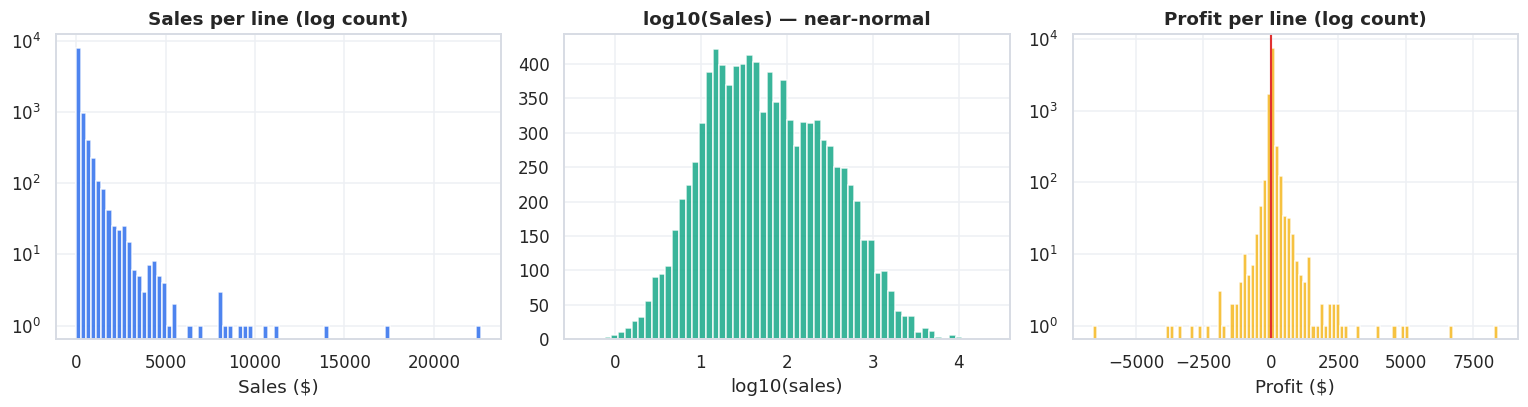

Sales  skew: 12.97   kurtosis: 305.28
Profit skew: 7.56   kurtosis: 397.15
Median sale $54.48 vs mean $229.85


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))

ax[0].hist(df.sales, bins=80, color=BLUE, alpha=.85); ax[0].set_yscale("log")
ax[0].set_title("Sales per line (log count)"); ax[0].set_xlabel("Sales ($)")

ax[1].hist(np.log10(df.sales.clip(lower=.1)), bins=60, color=TEAL, alpha=.85)
ax[1].set_title("log10(Sales) — near-normal"); ax[1].set_xlabel("log10(sales)")

ax[2].hist(df.profit, bins=100, color=AMBER, alpha=.85); ax[2].set_yscale("log")
ax[2].axvline(0, color=RED, lw=1.4)
ax[2].set_title("Profit per line (log count)"); ax[2].set_xlabel("Profit ($)")
plt.tight_layout(); plt.savefig(IMAGES / "distributions_eda.png"); plt.show()

print(f"Sales  skew: {df.sales.skew():.2f}   kurtosis: {df.sales.kurtosis():.2f}")
print(f"Profit skew: {df.profit.skew():.2f}   kurtosis: {df.profit.kurtosis():.2f}")
print(f"Median sale ${df.sales.median():,.2f} vs mean ${df.sales.mean():,.2f}")

**Sales are heavily right-skewed** (skew ≈ 12.9): the mean is more than three times the
median, so the mean is a misleading summary. Medians are used for typical-value statements
throughout, and log scales for the charts.

The log transform is close to normal, which matters if this ever feeds a model.

## 2. Outlier detection

In [4]:
def iqr_bounds(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

rows = []
for col in ["sales", "profit", "quantity", "discount", "shipping_days"]:
    lo, hi = iqr_bounds(df[col].dropna())
    mask = (df[col] < lo) | (df[col] > hi)
    rows.append({"column": col, "lower": round(lo,2), "upper": round(hi,2),
                 "outliers": int(mask.sum()),
                 "pct": round(mask.mean()*100, 2),
                 "skew": round(df[col].skew(), 2)})
pd.DataFrame(rows)

,column,lower,upper,outliers,pct,skew
0,sales,-271.71,498.93,1167,11.68,12.97
1,profit,-39.72,70.81,1881,18.82,7.56
2,quantity,-2.50,9.50,170,1.70,1.28
3,discount,-0.30,0.50,856,8.57,1.68
4,shipping_days,0.00,8.00,0,0.00,-0.42


In [5]:
extremes = pd.concat([
    df.nlargest(3, "sales")[["product_name","sales","profit","discount"]],
    df.nsmallest(3, "profit")[["product_name","sales","profit","discount"]],
])
extremes

,product_name,sales,profit,discount
2697,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48","-1,811.08",0.50
6825,Canon imageCLASS 2200 Advanced Copier,"17,499.95","8,399.98",0.00
8152,Canon imageCLASS 2200 Advanced Copier,"13,999.96","6,719.98",0.00
7771,Cubify CubeX 3D Printer Double Head Print,"4,499.98","-6,599.98",0.70
683,Cubify CubeX 3D Printer Triple Head Print,"7,999.98","-3,839.99",0.50
9773,GBC DocuBind P400 Electric Binding System,"2,177.58","-3,701.89",0.80


**Decision: outliers are kept.** The largest sale is a $22,638 videoconferencing unit sold
at a 50% discount — and it *lost* $1,811. The largest losses are all deeply discounted
machines and binding systems.

These are not data errors. They are the exact transactions the analysis is about; removing
them would delete the finding. Skew is handled with log scales, not by dropping rows.

## 3. Correlation

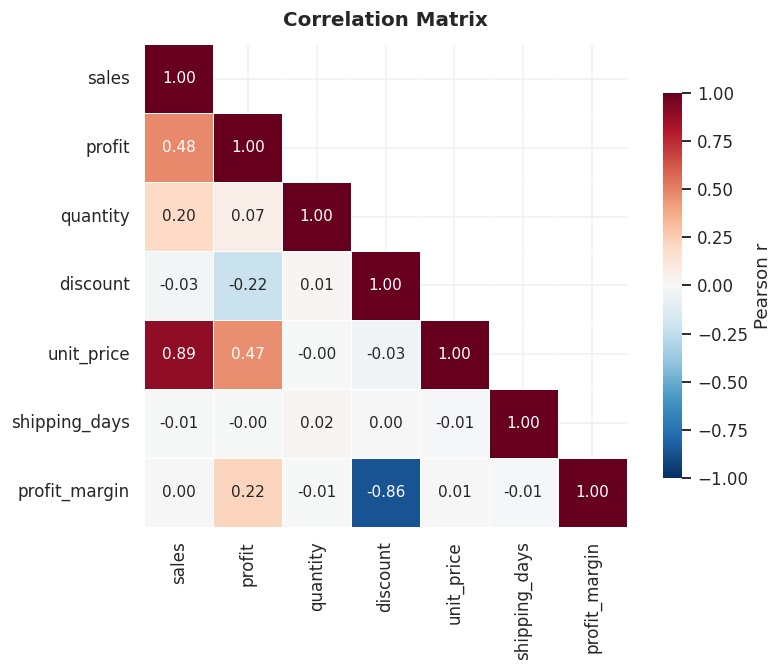

,corr with profit
discount,-0.22
shipping_days,-0.00
quantity,0.07
profit_margin,0.22
unit_price,0.47
sales,0.48


In [6]:
num = df[["sales", "profit", "quantity", "discount", "unit_price",
          "shipping_days", "profit_margin"]]
corr = num.corr()

fig, ax = plt.subplots(figsize=(8, 6.2))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={"shrink": .8, "label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Matrix", fontsize=13, weight="bold", pad=12)
plt.tight_layout(); plt.savefig(IMAGES / "correlation_heatmap.png"); plt.show()

corr["profit"].drop("profit").sort_values().to_frame("corr with profit")

**Reading it carefully.** Discount correlates with profit at only about −0.22, which looks
weak — but Pearson measures *linear* association, and the relationship is not linear. It is
a threshold effect: nothing much happens up to 30%, then margin collapses. A single
correlation coefficient hides that entirely, which is why the next section bands the data
instead of trusting the coefficient.

`profit_margin` correlates with discount far more strongly (≈ −0.36), because margin is
scale-free while raw profit is dominated by order size.

## 4. Does discounting reduce profit?

In [7]:
bands = ["No discount", "1-15%", "16-30%", "31-50%", "50%+"]
disc = (df.groupby("discount_band", observed=True)
          .agg(lines=("sales","size"), sales=("sales","sum"),
               profit=("profit","sum"), loss_lines=("is_loss","sum"))
          .reindex(bands))
disc["margin_%"] = disc.profit / disc.sales * 100
disc["loss_rate_%"] = disc.loss_lines / disc.lines * 100
disc

,lines,sales,profit,loss_lines,margin_%,loss_rate_%
discount_band,,,,,,
No discount,4798,"1,087,908.47","320,987.60",0,29.51,0.00
1-15%,146,"81,927.87","10,448.17",21,12.75,14.38
16-30%,3883,"867,539.65","79,980.09",709,9.22,18.26
31-50%,310,"195,314.76","-48,447.73",284,-24.80,91.61
50%+,856,"64,228.74","-76,559.05",856,-119.20,100.00


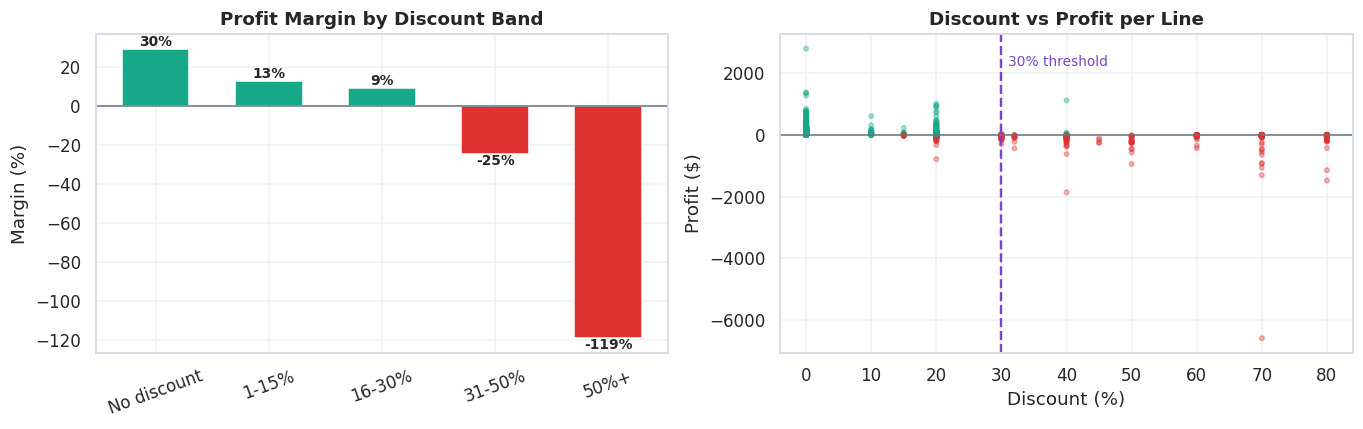

Lines above 30% discount: 1,166 (11.7%)
Profit destroyed        : $-125,006.78
Profit without them     : $411,415.86


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))

cols = [RED if v < 0 else TEAL for v in disc["margin_%"]]
ax[0].bar(disc.index, disc["margin_%"], color=cols, width=.6)
ax[0].axhline(0, color="#6b7280", lw=1); ax[0].tick_params(axis="x", rotation=20)
ax[0].set_title("Profit Margin by Discount Band"); ax[0].set_ylabel("Margin (%)")
for x, v in zip(disc.index, disc["margin_%"]):
    ax[0].text(x, v, f"{v:.0f}%", ha="center",
               va="bottom" if v > 0 else "top", fontsize=9, weight="bold")

s = df.sample(min(3000, len(df)), random_state=7)
ax[1].scatter(s.discount*100, s.profit, s=9, alpha=.35,
              c=[RED if p < 0 else TEAL for p in s.profit])
ax[1].axhline(0, color="#6b7280", lw=1)
ax[1].axvline(30, color=PURPLE, ls="--", lw=1.6)
ax[1].text(31, s.profit.max()*.8, "30% threshold", color=PURPLE, fontsize=9)
ax[1].set_title("Discount vs Profit per Line")
ax[1].set_xlabel("Discount (%)"); ax[1].set_ylabel("Profit ($)")
plt.tight_layout(); plt.savefig(IMAGES / "discount_impact.png"); plt.show()

deep = df[df.discount > .30]
print(f"Lines above 30% discount: {len(deep):,} ({len(deep)/len(df)*100:.1f}%)")
print(f"Profit destroyed        : ${deep.profit.sum():,.2f}")
print(f"Profit without them     : ${df[df.discount <= .30].profit.sum():,.2f}")

**Yes — but only past a threshold.** Margin is +29.5% at full price, holds at +9.2% through
30%, then falls to −24.8% and −119.2%. Just 11.7% of lines sit above 30% and they destroy
**$125,007** against total profit of $286,409.

## 5. Which month has the highest sales?

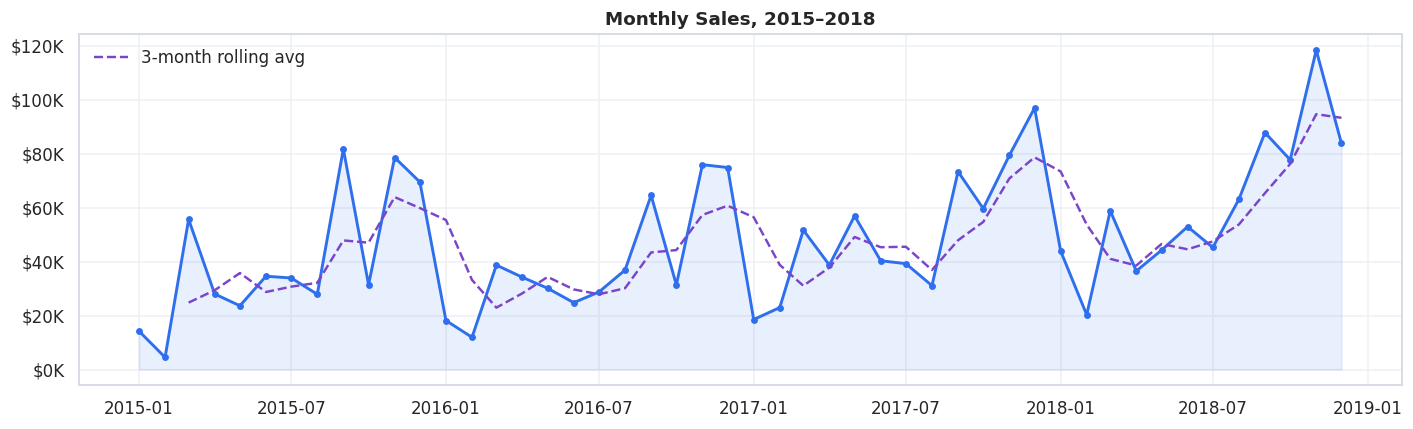

Strongest months: November, December, September
Weakest months  : February, January, April


In [9]:
monthly = df.groupby("year_month").agg(sales=("sales","sum"), profit=("profit","sum")).reset_index()
monthly["date"] = pd.to_datetime(monthly.year_month)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly.date, monthly.sales, color=BLUE, lw=1.9, marker="o", ms=3.5)
ax.fill_between(monthly.date, monthly.sales, color=BLUE, alpha=.10)
ax.plot(monthly.date, monthly.sales.rolling(3).mean(), color=PURPLE, lw=1.6, ls="--",
        label="3-month rolling avg")
ax.set_title("Monthly Sales, 2015–2018"); ax.yaxis.set_major_formatter(money)
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(IMAGES / "sales_trend.png"); plt.show()

season = df.groupby("order_month").sales.sum() / df.order_year.nunique()
print("Strongest months:", ", ".join(
    pd.Timestamp(2020, m, 1).strftime("%B") for m in season.nlargest(3).index))
print("Weakest months  :", ", ".join(
    pd.Timestamp(2020, m, 1).strftime("%B") for m in season.nsmallest(3).index))

## 6. Which category performs best?

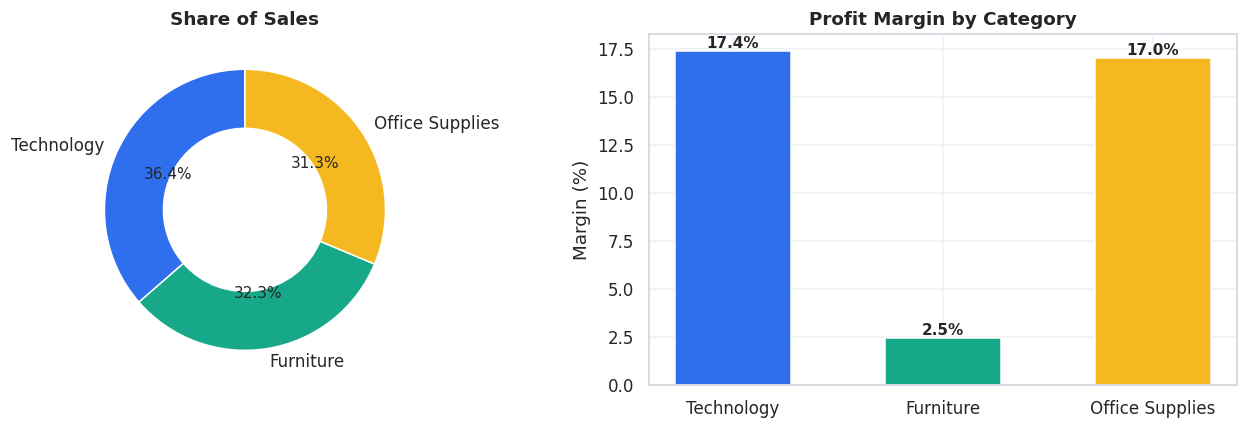

,sales,profit,margin,share
category,,,,
Technology,"836,154.03","145,454.95",17.40,36.40
Furniture,"741,718.42","18,463.33",2.49,32.29
Office Supplies,"719,047.03","122,490.80",17.04,31.30


In [10]:
cat = (df.groupby("category").agg(sales=("sales","sum"), profit=("profit","sum"))
         .assign(margin=lambda d: d.profit/d.sales*100,
                 share=lambda d: d.sales/d.sales.sum()*100)
         .sort_values("sales", ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].pie(cat.sales, labels=cat.index, autopct="%1.1f%%", startangle=90,
          colors=[BLUE, TEAL, AMBER], wedgeprops=dict(width=.42, edgecolor="w"))
ax[0].set_title("Share of Sales")
ax[1].bar(cat.index, cat.margin, color=[BLUE, TEAL, AMBER], width=.55)
ax[1].set_title("Profit Margin by Category"); ax[1].set_ylabel("Margin (%)")
for x, v in zip(cat.index, cat.margin):
    ax[1].text(x, v, f"{v:.1f}%", ha="center", va="bottom", weight="bold")
plt.tight_layout(); plt.savefig(IMAGES / "category_performance.png"); plt.show()
cat

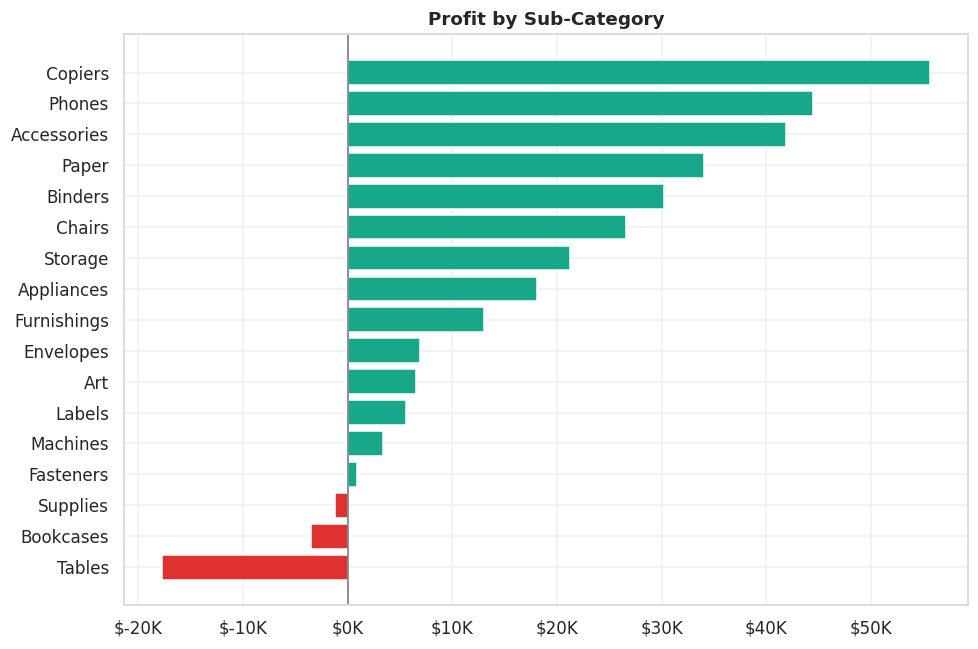

,sales,profit,discount,margin
sub_category,,,,
Tables,"206,965.53","-17,725.48",0.26,-8.56
Bookcases,"114,880.00","-3,472.56",0.21,-3.02
Supplies,"46,673.54","-1,189.10",0.08,-2.55


In [11]:
sub = (df.groupby("sub_category").agg(sales=("sales","sum"), profit=("profit","sum"),
                                      discount=("discount","mean"))
         .assign(margin=lambda d: d.profit/d.sales*100).sort_values("profit"))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sub.index, sub.profit, color=[RED if v < 0 else TEAL for v in sub.profit])
ax.axvline(0, color="#6b7280", lw=1)
ax.set_title("Profit by Sub-Category"); ax.xaxis.set_major_formatter(money)
plt.tight_layout(); plt.savefig(IMAGES / "profit_analysis.png"); plt.show()
sub[sub.profit < 0]

**Furniture is 32% of revenue at a 2.5% margin.** Tables lose $17,725 and Bookcases $3,473.
Tables carry a 26% average discount — the deepest in the catalogue.

## 7. Which states and cities lose money?

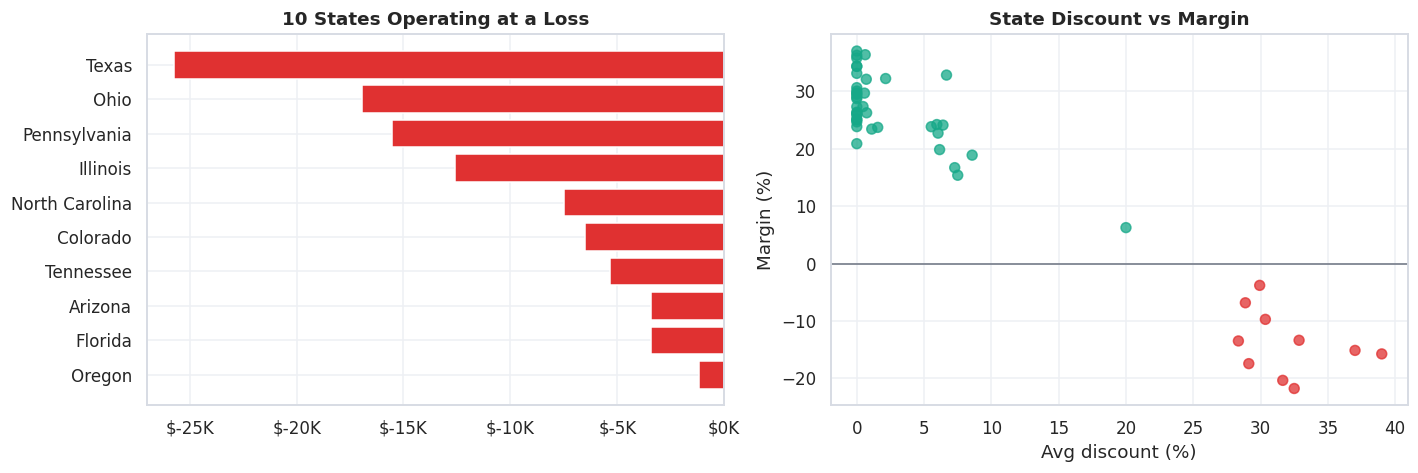

Loss states avg discount    : 32.0%
Profitable states avg disc. : 2.3%


In [12]:
state = (df.groupby(["state","region"]).agg(sales=("sales","sum"), profit=("profit","sum"),
                                            discount=("discount","mean"))
           .assign(margin=lambda d: d.profit/d.sales*100).reset_index())
losers = state[state.profit < 0].sort_values("profit")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].barh(losers.state[::-1], losers.profit[::-1], color=RED)
ax[0].set_title(f"{len(losers)} States Operating at a Loss")
ax[0].xaxis.set_major_formatter(money)

ax[1].scatter(state.discount*100, state.margin, s=42, alpha=.75,
              c=[RED if m < 0 else TEAL for m in state.margin])
ax[1].axhline(0, color="#6b7280", lw=1)
ax[1].set_title("State Discount vs Margin")
ax[1].set_xlabel("Avg discount (%)"); ax[1].set_ylabel("Margin (%)")
plt.tight_layout(); plt.savefig(IMAGES / "state_performance.png"); plt.show()

print(f"Loss states avg discount    : {losers.discount.mean()*100:.1f}%")
print(f"Profitable states avg disc. : {state[state.profit>0].discount.mean()*100:.1f}%")

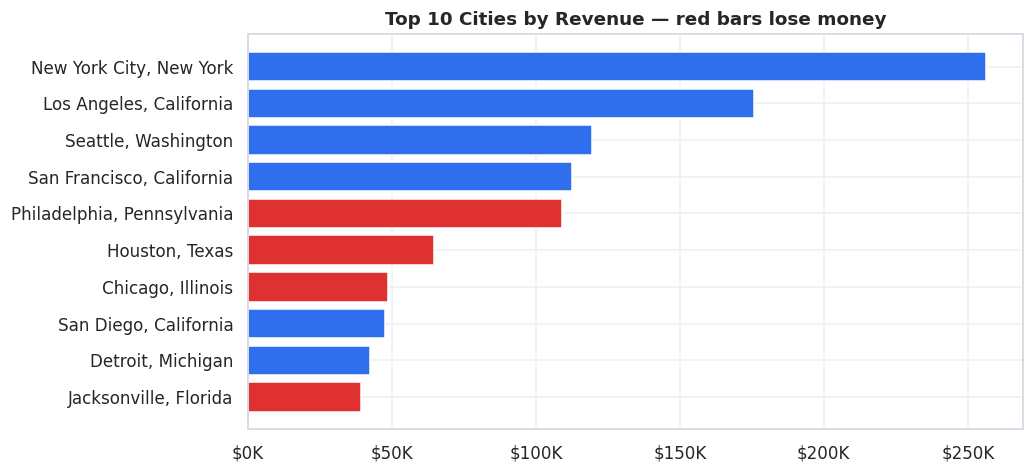

,label,sales,profit,margin
0,"New York City, New York","256,368.16","62,036.98",24.20
1,"Los Angeles, California","175,851.34","30,440.76",17.31
2,"Seattle, Washington","119,540.74","29,156.10",24.39
3,"San Francisco, California","112,669.09","17,507.39",15.54
4,"Philadelphia, Pennsylvania","109,077.01","-13,837.77",-12.69
5,"Houston, Texas","64,504.76","-10,153.55",-15.74
6,"Chicago, Illinois","48,539.54","-6,654.57",-13.71
7,"San Diego, California","47,521.03","6,377.20",13.42
8,"Detroit, Michigan","42,446.94","13,181.79",31.05
9,"Jacksonville, Florida","39,133.33","-2,445.66",-6.25


In [13]:
city = (df.groupby(["city","state"]).agg(sales=("sales","sum"), profit=("profit","sum"))
          .assign(margin=lambda d: d.profit/d.sales*100)
          .sort_values("sales", ascending=False).head(10).reset_index())
city["label"] = city.city + ", " + city.state

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.barh(city.label[::-1], city.sales[::-1],
        color=[RED if p < 0 else BLUE for p in city.profit[::-1]])
ax.set_title("Top 10 Cities by Revenue — red bars lose money")
ax.xaxis.set_major_formatter(money)
plt.tight_layout(); plt.savefig(IMAGES / "city_performance.png"); plt.show()
city[["label","sales","profit","margin"]]

**Philadelphia is the fifth-largest city by revenue and loses $13,838.** Houston is sixth
and loses $10,154. Revenue rank and profit contribution are not the same thing, and a
revenue-only view of the business would rank both as successes.

Every loss-making state discounts at 28–40%, against 10.9% in West. The geographic pattern
is the discount pattern.

## 8. Which segment and shipping mode perform best?

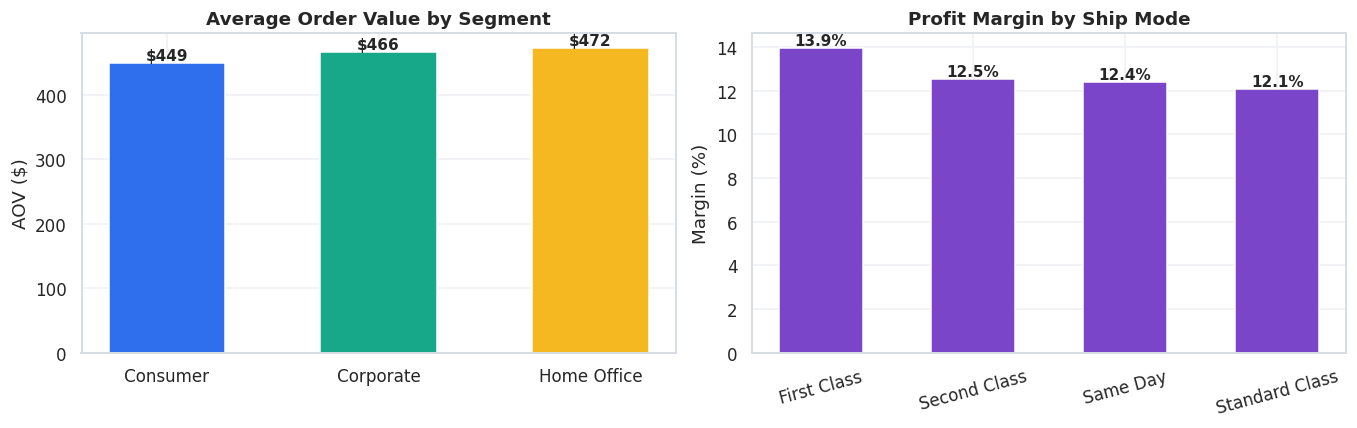

,customers,orders,sales,profit,margin,aov
segment,,,,,,
Consumer,409,2586,"1,161,401.34","134,119.21",11.55,449.11
Corporate,236,1514,"706,146.37","91,979.13",13.03,466.41
Home Office,148,909,"429,371.78","60,310.74",14.05,472.36


,orders,avg_days,sales,profit,margin
ship_mode,,,,,
First Class,787,2.18,"351,428.42","48,969.84",13.93
Second Class,964,3.24,"459,193.57","57,446.64",12.51
Same Day,264,0.04,"128,363.12","15,891.76",12.38
Standard Class,2994,5.01,"1,357,934.37","164,100.85",12.08


In [14]:
seg = (df.groupby("segment").agg(customers=("customer_id","nunique"),
                                 orders=("order_id","nunique"), sales=("sales","sum"),
                                 profit=("profit","sum"))
         .assign(margin=lambda d: d.profit/d.sales*100,
                 aov=lambda d: d.sales/d.orders).sort_values("sales", ascending=False))

ship = (df.groupby("ship_mode").agg(orders=("order_id","nunique"),
                                    avg_days=("shipping_days","mean"),
                                    sales=("sales","sum"), profit=("profit","sum"))
          .assign(margin=lambda d: d.profit/d.sales*100).sort_values("margin", ascending=False))

fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
ax[0].bar(seg.index, seg.aov, color=[BLUE, TEAL, AMBER], width=.55)
ax[0].set_title("Average Order Value by Segment"); ax[0].set_ylabel("AOV ($)")
for x, v in zip(seg.index, seg.aov):
    ax[0].text(x, v, f"${v:,.0f}", ha="center", va="bottom", weight="bold")
ax[1].bar(ship.index, ship.margin, color=PURPLE, width=.55)
ax[1].set_title("Profit Margin by Ship Mode"); ax[1].set_ylabel("Margin (%)")
ax[1].tick_params(axis="x", rotation=15)
for x, v in zip(ship.index, ship.margin):
    ax[1].text(x, v, f"{v:.1f}%", ha="center", va="bottom", weight="bold")
plt.tight_layout(); plt.savefig(IMAGES / "segment_shipping.png"); plt.show()
display(seg, ship)

**Home Office has the highest average order value** ($472) despite being the smallest
segment — worth noting against the assumption that Corporate buys biggest.

**Standard Class carries the lowest margin (12.1%) and misses the 5-day SLA on 30.6% of
lines.** First Class is both faster and higher-margin, which is counter-intuitive and worth
a follow-up: it suggests the cheap shipping option is attached to the discount-heavy orders.

→ Continue to `04_visualization.ipynb`